In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(140, 170)

150

In [4]:
random.randint(160, 195)

189

In [5]:
data = []
for i in range(50):
    #print(i)
    #여자데이터(몸무게와 키) 추가
    data.append([random.randint(40,70), random.randint(140,170)])
    #남자데이터(몸무게와 키) 추가
    data.append([random.randint(60,95), random.randint(160,195)])

In [6]:
print('여자몸무게(x축) :',[female[0] for female in data[::2]])
print('여자키(y축) :',[female[1] for female in data[::2]])

print('남자몸무게(x축) :',[male[0] for male in data[1::2]])
print('남자키(y축) :',[male[1] for male in data[1::2]])

여자몸무게(x축) : [45, 66, 62, 67, 55, 42, 42, 48, 43, 55, 59, 67, 65, 40, 56, 52, 54, 43, 44, 53, 54, 67, 64, 50, 54, 44, 52, 52, 50, 60, 63, 60, 50, 68, 55, 62, 61, 44, 46, 44, 66, 57, 43, 56, 47, 55, 62, 68, 50, 55]
여자키(y축) : [158, 164, 166, 164, 161, 149, 153, 156, 141, 142, 153, 156, 165, 161, 154, 168, 140, 161, 158, 167, 162, 146, 163, 141, 151, 163, 170, 154, 159, 151, 144, 165, 152, 145, 149, 167, 159, 142, 153, 170, 140, 160, 169, 163, 150, 154, 153, 149, 153, 152]
남자몸무게(x축) : [81, 93, 73, 68, 86, 63, 77, 88, 67, 87, 80, 60, 81, 84, 95, 88, 67, 66, 85, 73, 69, 68, 77, 92, 85, 60, 92, 80, 91, 79, 84, 82, 85, 61, 68, 67, 78, 92, 79, 74, 90, 63, 85, 75, 77, 83, 84, 77, 89, 72]
남자키(y축) : [175, 176, 167, 192, 160, 180, 189, 160, 160, 173, 162, 179, 165, 165, 192, 166, 170, 171, 175, 185, 189, 177, 168, 175, 187, 184, 171, 167, 174, 191, 176, 172, 187, 165, 172, 181, 172, 172, 178, 163, 171, 179, 160, 182, 180, 193, 174, 176, 176, 189]


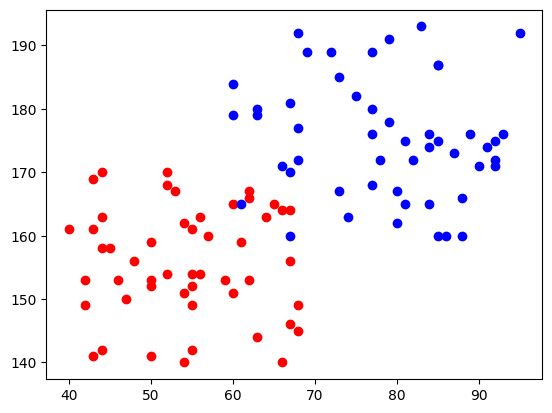

In [7]:
plt.plot([female[0] for female in data[::2]],
        [female[1] for female in data[::2]],'o', color='r')
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]],'o', color='b')
plt.show()

# 2. 군집화 로직

In [10]:
#초기 랜덤 지점 2개
random_points = [
    [random.randint(40,90),random.randint(140,195)],
    [random.randint(40,90),random.randint(140,195)]
]
random_points[0],random_points[1]

([52, 172], [79, 160])

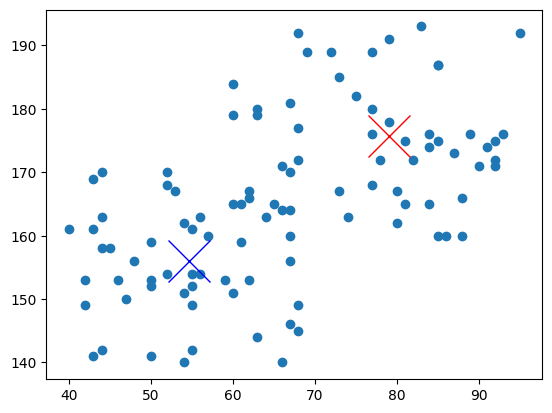

In [38]:
plt.plot([d[0] for d in data],[d[1] for d in data],'o')
plt.plot(random_points[0][0],random_points[0][1],'x',markersize=30,color='b') # 기준점0
plt.plot(random_points[1][0],random_points[1][1],'x',markersize=30,color='r') # 기준점1

In [39]:
# 두점 거리를 return하는 함수 점은 [0,0]
def dist(a,b):
    return np.sqrt((a[0]-b[0])**2+(a[1]-b[1])**2)
print(dist([3,4],[0,0]))

5.0


In [40]:
#random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0=[]
group1=[]
for d in data:
    if dist(random_points[0],d) < dist(random_points[1],d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)
        


(52, 48)

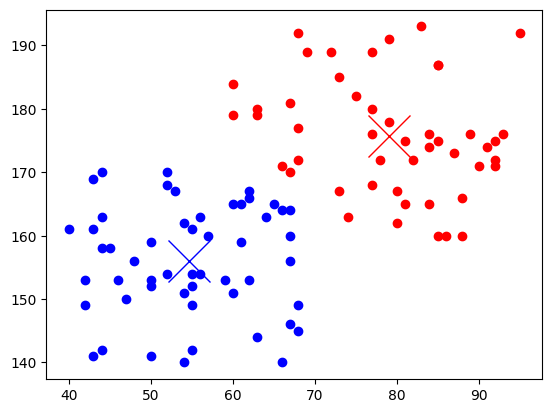

In [41]:
#group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0],'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1],'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')

In [36]:
#기준점을 이동 group0과 group1 중심점으로 기준점을 이동
group0_meanX=np.mean([d[0] for d in group0])
group0_meanY=np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX,group0_meanY]
random_points[0]

[54.71153846153846, 155.98076923076923]

In [37]:
group1_meanX=np.mean([d[0] for d in group1])
group1_meanY=np.mean([d[1] for d in group1])
random_points[1] = [group1_meanX,group1_meanY]
random_points[1]

[79.0, 175.79166666666666]

In [19]:
random_points

[[55.36538461538461, 163.55769230769232],
 [78.29166666666667, 167.58333333333334]]

# 3. 군집화 전체 코드(for문 이용)
- 랜덤포인트 2개 지정 - 출력 및 시각화 
- for문
    * 랜덤포인트 2지점 기준으로 group0과 group1을 나눔
    * group0의 중간점과 group1의 중간지점을 랜덤포인트로 업데이트
    * 랜덤포인트 출력 및 시각화
  


초기 지점 :  [[58, 144], [65, 166]]
1 번째 points:  [[53.10344827586207, 149.79310344827587], [71.78873239436619, 171.90140845070422]]
2 번째 points:  [[52.833333333333336, 153.85714285714286], [76.17241379310344, 173.91379310344828]]
3 번째 points:  [[53.854166666666664, 155.22916666666666], [77.92307692307692, 174.96153846153845]]
4 번째 points:  [[54.470588235294116, 155.8235294117647], [78.75510204081633, 175.55102040816325]]
5 번째 points:  [[54.71153846153846, 155.98076923076923], [79.0, 175.79166666666666]]
6 번째 points:  [[54.71153846153846, 155.98076923076923], [79.0, 175.79166666666666]]
7 번째 points:  [[54.71153846153846, 155.98076923076923], [79.0, 175.79166666666666]]
8 번째 points:  [[54.71153846153846, 155.98076923076923], [79.0, 175.79166666666666]]
9 번째 points:  [[54.71153846153846, 155.98076923076923], [79.0, 175.79166666666666]]
10 번째 points:  [[54.71153846153846, 155.98076923076923], [79.0, 175.79166666666666]]
11 번째 points:  [[54.71153846153846, 155.98076923076923], [79.0, 175.79166

(140.0, 195.0)

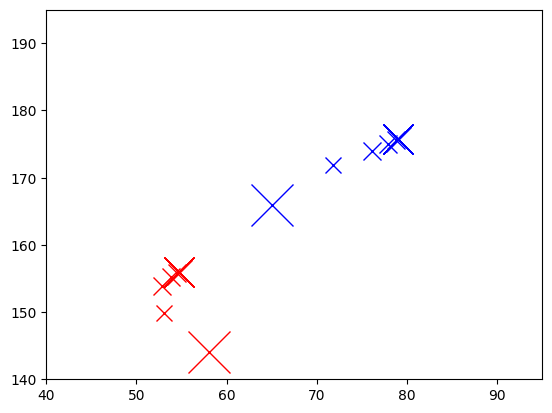

In [122]:
points= [
    [random.randint(40,95),random.randint(140,195)],
    [random.randint(40,95),random.randint(140,195)]
]
print('초기 지점 : ',points)
plt.plot(points[0][0],points[0][1],'x',color='r',markersize=30)
plt.plot(points[1][0],points[1][1],'x',color='b',markersize=30)
for i in range(1,50):
    # points 두 지점을 기준으로 group0과 group1 나누기
    group0=[]
    group1=[]
    for info in data:
        if dist(points[0],info) < dist(points[1],info):
            group0.append(info)
        else:
            group1.append(info)
    # group0의 중간점, group1의 중간점으로 points 업데이트
    group0_meanX = np.mean([g[0] for g in group0])
    group0_meanY = np.mean([g[1] for g in group0])
    group1_meanX = np.mean([g[0] for g in group1])
    group1_meanY = np.mean([g[1] for g in group1])
    points[0]=[group0_meanX,group0_meanY]
    points[1]=[group1_meanX,group1_meanY]
    #업데이트된 points 출력 및 시각화
    print(i, '번째 points: ', points)
    plt.plot(points[0][0],points[0][1],'x',color='r',markersize=12+(i*0.2))
    plt.plot(points[1][0],points[1][1],'x',color='b',markersize=12+(i*0.2))
plt.xlim([40,95])        
plt.ylim([140,195])   

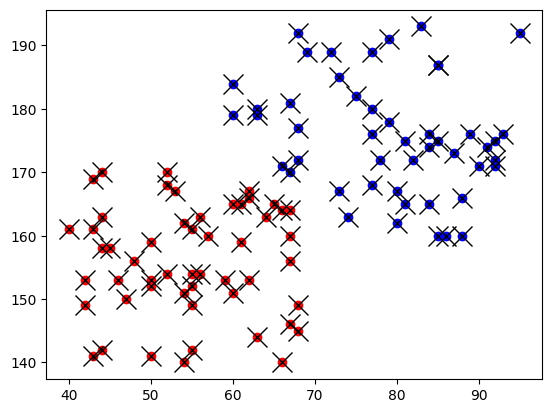

In [124]:
plt.plot([g[0] for g in group0],
        [g[1] for g in group0], 'o',color='r')
plt.plot([g[0] for g in group1],
        [g[1] for g in group1], 'o',color='b')
plt.plot([female[0] for female in data[::2]],
        [female[1] for female in data[::2]], 'x',color='k',markersize=15)
plt.plot([male[0] for male in data[1::2]],
        [male[1] for male in data[1::2]], 'x',color='k',markersize=15)

# 4. api(sklearn)를 이용한 군집화 
- sklearn : 머신러닝 패키지
    * 예측모델 : 회귀분석, 분류분석, 군집분석 - fit(학습), predict(예측,분류)
    * 군집모델 : 군집분석
    * 변환모델 : 전처리시 사용 ex. 인코딩, 스케일조정... - fit(학습), transform(변환함수), 
                fit_transform(학습과 변환을 같이)

In [ ]:

# import warnings
# warnings.filterwarnings(action='ingore')# 경고무시

In [142]:
from sklearn.cluster import KMeans
data = np.array(data) # 원칙적으로 머신러닝 모델엔 넘파이 배열로 학습
model = KMeans(n_clusters=2, # 2개 그룹으로 군집화
               init='random', # 초기포인트를 random하게 
               n_init=10, # 10벌 실행
              random_state=7) #일관적인 모델을 생성하기 위한 seed값
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [ ]:
# 두 그룹의 기준점 [[54.71153846153846, 155.98076923076923], [79.0, 175.79166666666666]]

In [143]:
model.cluster_centers_

array([[ 79.        , 175.79166667],
       [ 54.71153846, 155.98076923]])

In [144]:
#나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [145]:
group1 = data[model.labels_==1]
group0 = data[model.labels_==0]

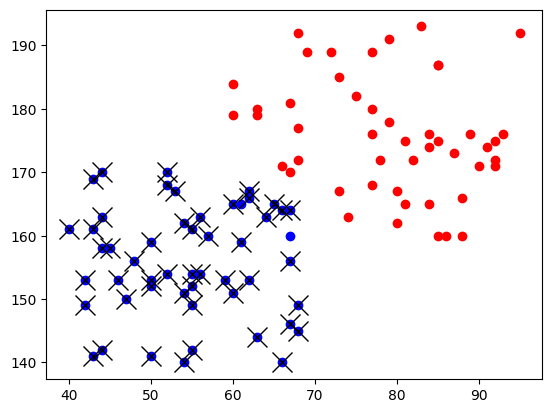

In [147]:
plt.plot([g[0] for g in group0],
        [g[1] for g in group0], 'o',color='r')
plt.plot([g[0] for g in group1],
        [g[1] for g in group1], 'o',color='b')
plt.plot([female[0] for female in data[::2]],
        [female[1] for female in data[::2]], 'x',color='k',markersize=15)
